# Matrix-free conjugate-gradient prediction (`predictIterative`) vs Cholesky factorization

## Context

Gaussian-process (Kriging) prediction needs, for both the mean **and** the standard deviation, to solve a linear system of the form

$$R\, x = v$$

where $R$ is the $n\times n$ correlation matrix of the fitted model (at fixed $\theta^\star$) and $v$ is a vector (one per prediction point for the standard deviation).

| Approach | Cost | Memory | Description |
|----------|------|--------|-------------|
| **Cholesky (`predict`, default)** | $\mathcal{O}(n^3)$ once, then $\mathcal{O}(n^2)$ per solve reusing the factor | $\mathcal{O}(n^2)$ (resident factor $L$) | Factorize $R = LL^\top$ once, then solve via triangular substitutions |
| **Matrix-free conjugate gradient (`predictIterative`)** | $\mathcal{O}(n^2\cdot\text{iters})$ per solve, nothing reused between solves | $\mathcal{O}(n)$ ($R$ is never stored) | Solve $Rx=v$ iteratively, only ever computing $R\,p$ products on the fly |

**Core idea behind `predictIterative`**: when the Cholesky factor $L$ was never computed (a model fitted with an approximate objective such as `LLVecchia`/`LLNystrom`/`LLIterative`, none of which ever maintain an $n\times n$ factor) — or simply when you don't want to keep it resident just for a handful of predictions on an otherwise ordinary fit — the same *exact* result (up to numerical tolerances) can be obtained without ever forming or factorizing $R$, just by evaluating it column by column through matrix-vector products.

This notebook walks through the linear algebra of both approaches on a small 1D running example, so that every step (matrix $R$, factor $L$, conjugate-gradient iterations) stays visible and interpretable.

**Code references**: [`PredictIterative.md`](PredictIterative.md), [`Nystrom.md`](Nystrom.md), [`Scalability.md`](Scalability.md), [`src/lib/LinearAlgebra.cpp`](../../src/lib/LinearAlgebra.cpp) (`LinearAlgebra::conjugateGradient`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pylibkriging as lk
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 4.5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Running example: 6 points in 1D

We use a simple 1D test function, with very few observation points ($n=6$) so that every intermediate matrix ($6\times 6$) stays small enough to display and read directly.

$$f(x) = \sin(6x) + 0.3\cos(18x)$$

We fit an **ordinary kriging** model: $y(x) = m + Z(x)$ with $m$ an unknown constant and $Z \sim \mathcal{GP}(0,\ \sigma^2\rho(x,x';\theta))$, Gaussian kernel $\rho(x,x';\theta)=\exp(-\|x-x'\|^2/\theta^2)$ (`regmodel='constant'` in libKriging).

In [2]:
def f(x):
    return np.sin(6*x) + 0.3*np.cos(18*x)

# 6 observation points, deliberately few and irregularly spaced
X_o = np.array([[0.05], [0.20], [0.40], [0.55], [0.75], [0.95]])
y_o = f(X_o[:, 0])
n = len(y_o)

X_grid = np.linspace(0, 1, 150).reshape(-1, 1)
y_true = f(X_grid[:, 0])

print(f'n = {n} observation points')
print('X_o =', X_o.ravel())
print('y_o =', np.round(y_o, 4))

n = 6 observation points
X_o = [0.05 0.2  0.4  0.55 0.75 0.95]
y_o = [ 0.482   0.663   0.858  -0.4245 -0.7991 -0.604 ]


theta* = 0.1463   sigma2* = 0.4345   beta* = -0.0039


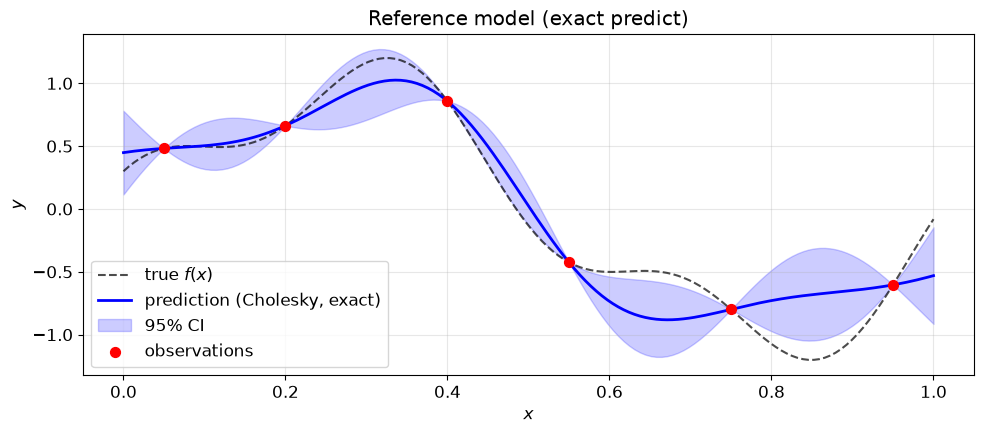

In [3]:
# Fit the Kriging model (reference: resident Cholesky factor)
model = lk.Kriging(y_o, X_o, 'gauss', regmodel='constant')
mean_exact, stdev_exact = model.predict(X_grid, return_stdev=True)[:2]
mean_exact, stdev_exact = mean_exact.ravel(), stdev_exact.ravel()

theta = model.theta().ravel()[0]
sigma2 = model.sigma2()
beta = model.beta().ravel()
print(f'theta* = {theta:.4f}   sigma2* = {sigma2:.4f}   beta* = {beta[0]:.4f}')

fig, ax = plt.subplots()
ax.plot(X_grid, y_true, 'k--', lw=1.5, alpha=0.7, label='true $f(x)$')
ax.plot(X_grid, mean_exact, 'b-', lw=2, label='prediction (Cholesky, exact)')
ax.fill_between(X_grid.ravel(), mean_exact - 1.96*stdev_exact, mean_exact + 1.96*stdev_exact,
                 alpha=0.2, color='blue', label='95% CI')
ax.scatter(X_o, y_o, c='red', zorder=5, s=50, label='observations')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$'); ax.legend(loc='lower left'); ax.set_title('Reference model (exact predict)')
plt.tight_layout(); plt.show()

## 2. Recap: what `predict()` does — Cholesky

The ordinary-kriging predictor (mean $\hat y$, variance $s^2$) at point $x$ is, with $\mathbb{1}$ the vector of $n$ ones, $y$ the observations, $\sigma^2$ the process variance, and $r$ the correlation vector between the prediction point $x$ and the $n$ observations:

$$
\hat{y}(x) = \hat{m} + r^\top R^{-1}(y - \hat{m}\,\mathbb{1})
\qquad\qquad
s^2(x) = \sigma^2\left(1 - r^\top R^{-1}r + \frac{\big(1 - \mathbb{1}^\top R^{-1}r\big)^2}{\mathbb{1}^\top R^{-1}\mathbb{1}}\right)
$$

where $\hat m$ (the constant mean, estimated by GLS at fit time) is already known — here we only care about the cost of *prediction*, not of fitting. The last term of $s^2(x)$ is the extra uncertainty coming from the fact that $m$ is *estimated* from the data rather than known in advance (this is what distinguishes ordinary kriging from simple kriging, where $m$ is fixed and this term vanishes).

In both formulas, the only costly algebraic operation is a product of the form $R^{-1}v$: $v = y-\hat m\,\mathbb{1}$ for the mean (computed **once**, shared across every prediction point), $v = r$ for the variance (**a different $r$ per prediction point**). In other words, everything reduces to solving, over and over, a linear system of the form

$$R\, x = v$$

where $R$ is the fitted model's $n\times n$ correlation matrix (at fixed $\theta^\star$) and $v$ is whichever right-hand side is needed at the time ($y-\hat m\,\mathbb{1}$ or $r$). **This is exactly the system Cholesky and the conjugate gradient each solve their own way**: Cholesky by factorizing $R$ once and reusing the factor for every new $v$ (§2), CG by solving it iteratively without ever forming $R$ (§3) — two different computational paths to the same $x=R^{-1}v$, hence to the same $\hat y(x)$ and $s^2(x)$.

### Factorization

$R$ being symmetric positive definite, we factorize $R = LL^\top$ with $L$ lower-triangular ($\mathcal{O}(n^3)$, once for the whole model).

**Why does $R=LL^\top$ help solve $Rx=v$?** Without factorization, solving an arbitrary $n\times n$ system (Gaussian elimination) costs $\mathcal{O}(n^3)$ — and that cost would have to be paid again **for every new $v$** (a different $v$ per prediction point for the variance). Cholesky's trick is to replace the dense system $Rx=v$ with two *triangular* systems:

$$Rx=v \iff LL^\top x = v \iff \underbrace{Lu = v}_{\text{forward}} \ \text{then}\ \underbrace{L^\top x = u}_{\text{backward}}$$

A triangular system is solved by plain substitution (each unknown is expressed directly from the previous ones, no elimination needed): $\mathcal{O}(n^2)$ instead of $\mathcal{O}(n^3)$. And crucially, **$L$ only depends on $R$, not on $v$**: once computed (the $\mathcal{O}(n^3)$ cost, paid once at fit time), it is reused as-is for any new right-hand side $v$ — every further prediction only costs the two $\mathcal{O}(n^2)$ substitutions above, never a fresh $\mathcal{O}(n^3)$. This is `predict()`'s default path: fast as long as $L$ ($\mathcal{O}(n^2)$ in memory) can stay resident.

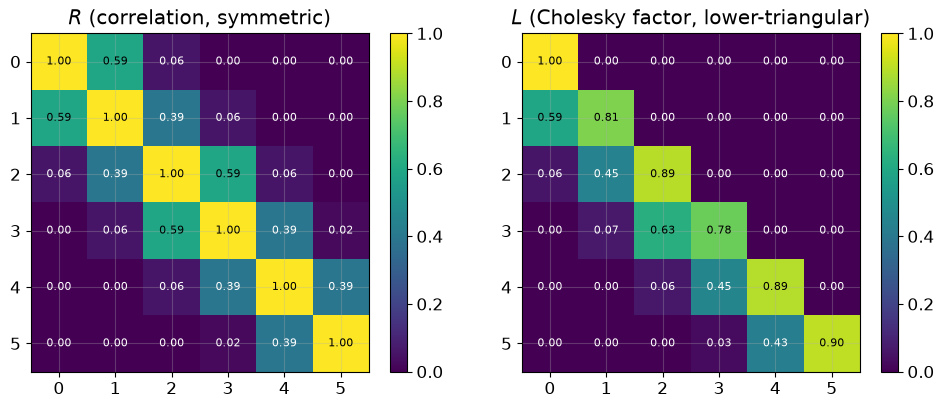

Check L L^T = R: True


In [4]:
# Reconstruct R and its Cholesky factor L at theta*
R = np.array(model.covMat(X_o, X_o)) / sigma2   # covMat() returns sigma2 * R
L = np.linalg.cholesky(R)                       # equivalent to libKriging's internal T

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, M, title in zip(axes, [R, L], ['$R$ (correlation, symmetric)', '$L$ (Cholesky factor, lower-triangular)']):
    im = ax.imshow(M, cmap='viridis', vmin=0)
    ax.set_title(title)
    for i in range(n):
        for j in range(n):
            if M[i, j] != 0 or True:
                ax.text(j, i, f'{M[i,j]:.2f}', ha='center', va='center',
                         color='white' if M[i, j] < M.max()/2 else 'black', fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

print('Check L L^T = R:', np.allclose(L @ L.T, R))

In [5]:
# "By hand" Cholesky solve: w = R^{-1}(y - m_hat * 1)
ones_n = np.array(model.F())       # n x 1, vector of ones (ordinary kriging: F = 1_n)
m_hat = beta                       # constant mean already estimated by the fit (GLS)
resid = y_o - (ones_n @ m_hat)

u = np.linalg.solve(L, resid)      # forward solve L u = resid          -- O(n^2)
w_chol = np.linalg.solve(L.T, u)   # backward solve L^T w = u          -- O(n^2)

# Reconstruct the predicted mean on the grid using this w
R_on = np.array(model.covMat(X_o, X_grid)) / sigma2   # n x q, obs<->grid correlations
ones_q = np.ones((X_grid.shape[0], 1))
mean_chol_manual = (ones_q @ m_hat + R_on.T @ w_chol).ravel()

print('max |manual mean (Cholesky) - exact predict()| =',
      np.abs(mean_chol_manual - mean_exact).max())

max |manual mean (Cholesky) - exact predict()| = 5.551115123125783e-16


## 3. The matrix-free conjugate gradient (CG)

The conjugate gradient (Hestenes & Stiefel, 1952) solves $Rx=v$ **without ever forming or factorizing $R$**: each iteration only needs a matrix-vector product $R p_k$, computed on the fly. This is exactly the algorithm implemented by `LinearAlgebra::conjugateGradient` in `src/lib/LinearAlgebra.cpp`.

**Initialization**: $x_0 = 0,\quad r_0 = v - Rx_0 = v,\quad p_0 = r_0$

**Iteration $k$**:

$$
\alpha_k = \frac{r_k^\top r_k}{p_k^\top R\, p_k}
\qquad\quad
x_{k+1} = x_k + \alpha_k p_k
\qquad\quad
r_{k+1} = r_k - \alpha_k R p_k
$$
$$
\beta_k = \frac{r_{k+1}^\top r_{k+1}}{r_k^\top r_k}
\qquad\quad
p_{k+1} = r_{k+1} + \beta_k p_k
$$

**Stopping**: as soon as the relative residual $\|r_k\|/\|v\|$ drops below a tolerance `tol` (default $10^{-8}$), or after `max_iter` iterations (default $2n$ in `predictIterative`: CG's classical exact-arithmetic bound is $n$ iterations, but Kriging covariance matrices are commonly ill-conditioned enough that round-off keeps the true error shrinking a bit past that point).

**Cost per iteration**: a single product $Rp_k$, i.e. $\mathcal{O}(n^2)$ flops and $\mathcal{O}(n)$ memory (only vectors are stored, $R$ never exists explicitly — in the C++ code, `Amul` is a lambda that evaluates $Rp$ column by column on demand). For $k$ iterations, the total cost is $\mathcal{O}(k\,n^2)$: cheaper than the $\mathcal{O}(n^3)$ Cholesky factorization as soon as $k \ll n$, but — unlike $L$ — **nothing carries over from one solve to the next**: every new system $Rx=v$ starts from scratch.

In [6]:
def conjugate_gradient(Amul, b, max_iter, tol=1e-12):
    # Matrix-free CG: Amul(p) computes R@p on the fly, R is never stored.
    x = np.zeros_like(b)
    r = b.copy()
    p = r.copy()
    bnorm = np.linalg.norm(b)
    history = {'x': [x.copy()], 'rel_resid': [1.0]}
    rz_old = r @ r
    for k in range(max_iter):
        Ap = Amul(p)
        alpha = rz_old / (p @ Ap)
        x = x + alpha * p
        r = r - alpha * Ap
        rel = np.linalg.norm(r) / bnorm
        history['x'].append(x.copy())
        history['rel_resid'].append(rel)
        if rel < tol:
            break
        rz_new = r @ r
        p = r + (rz_new / rz_old) * p
        rz_old = rz_new
    return x, history

# Solve R w = resid via matrix-free CG (Amul never sees a pre-stored R)
w_cg, hist = conjugate_gradient(lambda p: R @ p, resid, max_iter=n, tol=1e-14)

print(f"CG: {len(hist['rel_resid'])-1} iterations for n={n} (theoretical bound: n iterations)")
print('max |w_cg - w_chol| =', np.abs(w_cg - w_chol).max())

CG: 6 iterations for n=6 (theoretical bound: n iterations)
max |w_cg - w_chol| = 6.661338147750939e-16


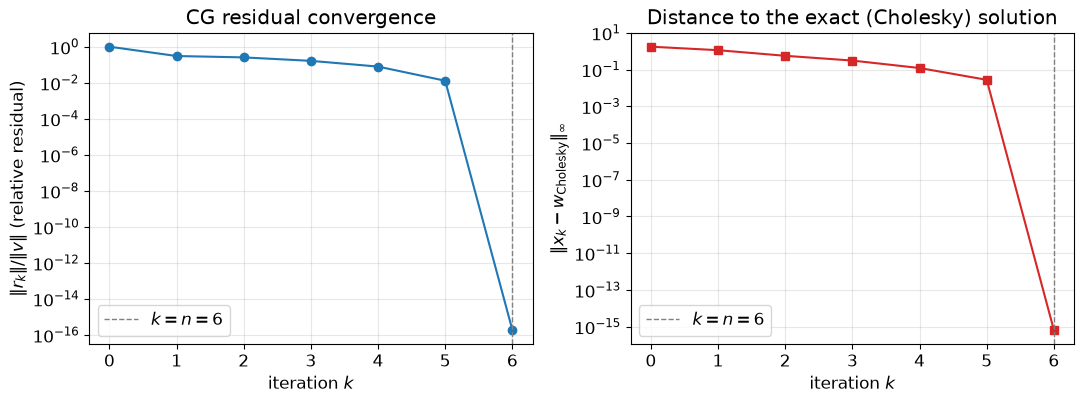

In [7]:
errs_to_exact = [np.abs(x - w_chol).max() for x in hist['x']]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].semilogy(range(len(hist['rel_resid'])), hist['rel_resid'], 'o-', color='#1f77b4')
axes[0].set_xlabel('iteration $k$'); axes[0].set_ylabel(r'$\|r_k\|/\|v\|$ (relative residual)')
axes[0].set_title('CG residual convergence')
axes[0].axvline(n, color='gray', ls='--', lw=1, label=f'$k=n={n}$')
axes[0].legend()

axes[1].semilogy(range(len(errs_to_exact)), np.maximum(errs_to_exact, 1e-17), 's-', color='#d62728')
axes[1].set_xlabel('iteration $k$'); axes[1].set_ylabel(r'$\|x_k - w_{\mathrm{Cholesky}}\|_\infty$')
axes[1].set_title('Distance to the exact (Cholesky) solution')
axes[1].axvline(n, color='gray', ls='--', lw=1, label=f'$k=n={n}$')
axes[1].legend()
plt.tight_layout(); plt.show()

**Reading the plots**: in exact arithmetic, CG solves an $n\times n$ system in **exactly $n$ iterations** (classical property: the directions $p_0,\dots,p_{n-1}$ form an $R$-conjugate basis of $\mathbb{R}^n$). We see it here — both the residual and the distance to the Cholesky solution collapse at $k=n=6$. On a real model with large $n$, one almost never runs all the way to $k=n$: convergence stops much earlier (`tol`), which is precisely what makes CG worthwhile — practical convergence is far faster than the theoretical bound when $R$'s spectrum is favorable (see §5).

## 4. Check: mean and standard deviation reconstructed via CG

We reconstruct the full prediction (mean **and** standard deviation) from the single $w_{\mathrm{CG}}$ obtained above, reusing exactly the formulas from §2, and compare against `predict()` (Cholesky) and `model.predictIterative()` (the C++ implementation of the same algorithm).

In [8]:
mean_cg = (ones_q @ m_hat + R_on.T @ w_cg).ravel()

one_Rinv_one = ones_n.T @ np.linalg.solve(R, ones_n)   # scalar: 1^T R^-1 1
stdev_cg = np.zeros(X_grid.shape[0])
for j in range(X_grid.shape[0]):
    r_on_j = R_on[:, j]
    # One CG solve PER PREDICTION POINT for the variance -- the dominant cost, see §5
    w_j, _ = conjugate_gradient(lambda p: R @ p, r_on_j, max_iter=n, tol=1e-14)
    correction = (1.0 - ones_n.ravel() @ w_j)**2 / one_Rinv_one.item()
    stdev_cg[j] = np.sqrt(max(0.0, sigma2 * (1.0 - r_on_j @ w_j + correction)))

mean_lib_cg, stdev_lib_cg = model.predictIterative(X_grid, return_stdev=True)

print('max mean diff    : hand-rolled CG vs exact Cholesky =', np.abs(mean_cg - mean_exact).max())
print('max stdev diff    : hand-rolled CG vs exact Cholesky =', np.abs(stdev_cg - stdev_exact).max())
print('max mean diff    : model.predictIterative() vs exact         =', np.abs(mean_lib_cg.ravel() - mean_exact).max())
print('max stdev diff    : model.predictIterative() vs exact         =', np.abs(stdev_lib_cg.ravel() - stdev_exact).max())

max mean diff    : hand-rolled CG vs exact Cholesky = 6.938893903907228e-16
max stdev diff    : hand-rolled CG vs exact Cholesky = 1.4230316144198119e-13
max mean diff    : model.predictIterative() vs exact         = 6.661338147750939e-16
max stdev diff    : model.predictIterative() vs exact         = 5.115092377439012e-14


**Result**: all three computational paths agree to machine precision, for both the mean and the standard deviation. The correction term $(1-\mathbb{1}^\top R^{-1}r)^2/(\mathbb{1}^\top R^{-1}\mathbb{1})$ from §2, computed here via one extra shared CG solve ($R^{-1}\mathbb{1}$, reused across every prediction point just like the mean's solve) instead of a triangular solve, is what makes the difference: without it, the standard deviation would reduce to the *simple*-kriging formula (known mean) and understate the uncertainty whenever a trend is estimated.

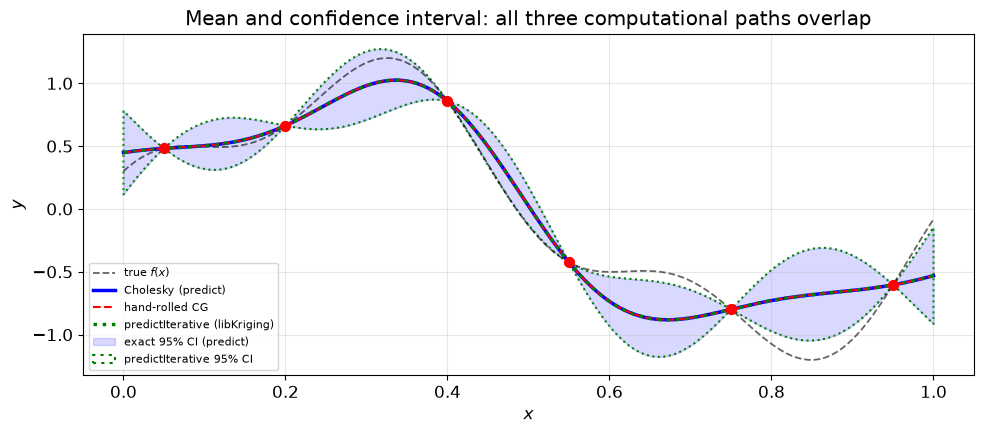

In [9]:
fig, ax = plt.subplots()
ax.plot(X_grid, y_true, 'k--', lw=1.3, alpha=0.6, label='true $f(x)$')
ax.plot(X_grid, mean_exact, 'b-', lw=2.5, label='Cholesky (predict)')
ax.plot(X_grid, mean_cg, 'r--', lw=1.5, label='hand-rolled CG')
ax.plot(X_grid, mean_lib_cg.ravel(), 'g:', lw=2.5, label='predictIterative (libKriging)')
ax.fill_between(X_grid.ravel(), mean_exact - 1.96*stdev_exact, mean_exact + 1.96*stdev_exact,
                 alpha=0.15, color='blue', label='exact 95% CI (predict)')
ax.fill_between(X_grid.ravel(), mean_lib_cg.ravel() - 1.96*stdev_lib_cg.ravel(),
                 mean_lib_cg.ravel() + 1.96*stdev_lib_cg.ravel(),
                 facecolor='none', edgecolor='green', linestyle=':', linewidth=1.5, label='predictIterative 95% CI')
ax.scatter(X_o, y_o, c='red', zorder=5, s=50)
ax.set_xlabel('$x$'); ax.set_ylabel('$y$'); ax.legend(loc='lower left', fontsize=8)
ax.set_title('Mean and confidence interval: all three computational paths overlap')
plt.tight_layout(); plt.show()

**Key point about the cost of the standard deviation**: the hand-rolled loop in §4 redoes **one CG solve per grid point** (150 points), whereas the mean only needs **one, shared** across every point. This is exactly why `predictIterative(..., return_stdev=True)` is *opt-in* in the API — its cost is $\mathcal{O}(n^2\cdot\text{iters}\cdot q)$ for $q$ prediction points, whereas the mean alone stays $\mathcal{O}(n^2\cdot\text{iters})$, in the same asymptotic class as the exact `predict()`'s *total* $\mathcal{O}(n^2)$ cost (which amortizes its factorization over every point).

## 5. Cholesky vs CG as a function of $n$: memory first, then compute cost

Beyond the $n=6$ example, two questions matter as $n$ grows: how much
**memory** does each approach need resident, and how many **flops** does
each prediction cost. Memory is the one usually asserted rather than shown
-- §5a measures it directly. §5b then covers the (already well-known)
theoretical flop trade-off for completeness.


### 5a. Measured memory footprint

`predict()` needs a resident Cholesky factor $L$ ($O(n^2)$);
`predictIterative()` needs $R$ never formed at all ($O(n)$) -- *provided*
the model was fitted without ever building $L$ in the first place (a
light `LLIterative` fit, see
[lliterative_vs_cholesky.ipynb](lliterative_vs_cholesky.ipynb)'s own memory
measurement of the *fit* side). Calling `predictIterative()` on an
*exactly*-fitted model doesn't demonstrate this -- $L$ would already be
resident from the fit itself, CG or not. So each point below is one
**fresh, isolated subprocess** that fits AND predicts, then reports its
own peak resident-set size
(`resource.getrusage(RUSAGE_SELF).ru_maxrss`) -- exact `LL` fit +
`predict()` vs. light `LLIterative` fit (`optim="none"`, fixed $\theta$,
same reasoning as the fit notebook: isolates memory from BFGS noise) +
`predictIterative()`. A fresh subprocess per point avoids the allocator
retaining memory across points within one long-lived process.


In [10]:
import subprocess, sys, tempfile, textwrap, os

probe_script = textwrap.dedent('''
    import sys, resource
    import numpy as np
    import pylibkriging as lk

    n = int(sys.argv[1])
    objective = sys.argv[2]

    np.random.seed(0)
    def f(x1, x2):
        return np.sin(3 * x1) * np.cos(3 * x2) * np.exp(-0.3 * (x1 + x2))

    X = np.random.uniform(0, 1, size=(n, 2))
    y = f(X[:, 0], X[:, 1]) + np.random.normal(0, 0.03, size=n)
    params = {'theta': np.array([[0.3, 0.3]]), 'is_theta_estim': False}

    k = lk.Kriging(y, X, 'matern5_2', regmodel='constant',
                   objective=objective, optim='none', parameters=params)
    Xt = np.random.uniform(0, 1, size=(5, X.shape[1]))
    if objective == 'LL':
        k.predict(Xt, True, False, False)
    else:
        k.predictIterative(Xt, True)

    peak_kb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    print(peak_kb)
''')

probe_path = tempfile.NamedTemporaryFile(suffix='.py', delete=False).name
with open(probe_path, 'w') as fh:
    fh.write(probe_script)


def measure_peak_mb(n, objective):
    out = subprocess.run([sys.executable, probe_path, str(n), objective],
                         capture_output=True, text=True, check=True, timeout=240)
    return int(out.stdout.strip()) / 1024  # KB -> MB


n_values_exact = [100, 300, 700, 1500, 3000, 6000]
n_values_iter = [50, 100, 150, 200]
m_fixed, precond_rank = 15, 20

mem_exact = [measure_peak_mb(n, 'LL') for n in n_values_exact]
for n, m in zip(n_values_exact, mem_exact):
    print(f'exact fit+predict()            n={n:5d}   peak RSS = {m:8.1f} MB')

mem_iter = [measure_peak_mb(n, f'LLIterative({m_fixed},{precond_rank})') for n in n_values_iter]
for n, m in zip(n_values_iter, mem_iter):
    print(f'LLIterative(15,20) fit+predictIterative()  n={n:5d}   peak RSS = {m:8.1f} MB')

os.unlink(probe_path)


exact fit+predict()            n=  100   peak RSS =    133.5 MB
exact fit+predict()            n=  300   peak RSS =    133.5 MB
exact fit+predict()            n=  700   peak RSS =    133.5 MB
exact fit+predict()            n= 1500   peak RSS =    187.1 MB
exact fit+predict()            n= 3000   peak RSS =    741.3 MB
exact fit+predict()            n= 6000   peak RSS =   3360.9 MB


LLIterative(15,20) fit+predictIterative()  n=   50   peak RSS =    133.6 MB
LLIterative(15,20) fit+predictIterative()  n=  100   peak RSS =    133.6 MB
LLIterative(15,20) fit+predictIterative()  n=  150   peak RSS =    133.6 MB
LLIterative(15,20) fit+predictIterative()  n=  200   peak RSS =    133.6 MB


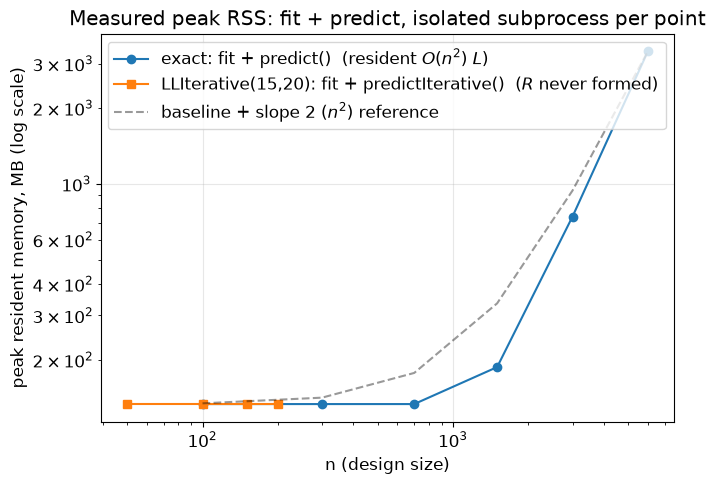

exact: 133 MB at n=100 -> 3361 MB at n=6000
LLIterative: 134 MB at n=50 -> 134 MB at n=200  (dominated by the fixed Python+numpy+pylibkriging baseline, barely moves with n)


In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(n_values_exact, mem_exact, 'o-', label='exact: fit + predict()  (resident $O(n^2)$ $L$)')
ax.loglog(n_values_iter, mem_iter, 's-',
          label=f'LLIterative({m_fixed},{precond_rank}): fit + predictIterative()  ($R$ never formed)')

n_arr = np.array(n_values_exact, dtype=float)
baseline = min(mem_exact[0], mem_iter[0])
ax.loglog(n_arr, baseline + (mem_exact[-1] - baseline) * (n_arr / n_arr[-1])**2,
          'k--', alpha=0.4, label=r'baseline + slope 2 ($n^2$) reference')

ax.set_xlabel('n (design size)')
ax.set_ylabel('peak resident memory, MB (log scale)')
ax.set_title('Measured peak RSS: fit + predict, isolated subprocess per point')
ax.legend()
plt.tight_layout()
plt.show()

print(f'exact: {mem_exact[0]:.0f} MB at n={n_values_exact[0]} -> {mem_exact[-1]:.0f} MB at n={n_values_exact[-1]}')
print(f'LLIterative: {mem_iter[0]:.0f} MB at n={n_values_iter[0]} -> {mem_iter[-1]:.0f} MB at n={n_values_iter[-1]}'
      f'  (dominated by the fixed Python+numpy+pylibkriging baseline, barely moves with n)')


### 5b. Theoretical compute cost (flops)

Memory isn't the only axis -- here's the well-known compute-cost trade-off
for completeness:

- **Cholesky**: $\mathcal{O}(n^3)$ to factorize (once), $+\ \mathcal{O}(n^2)$ per solve afterwards (reusing the factor)
- **CG**: $\mathcal{O}(k\, n^2)$ for $k$ iterations, **for every solve** (nothing is reused)

`predictIterative` defaults to $k = 2n$ iterations. The plot below compares, in flop count, the Cholesky factorization against $k$ iterations of CG for various values of $k$.


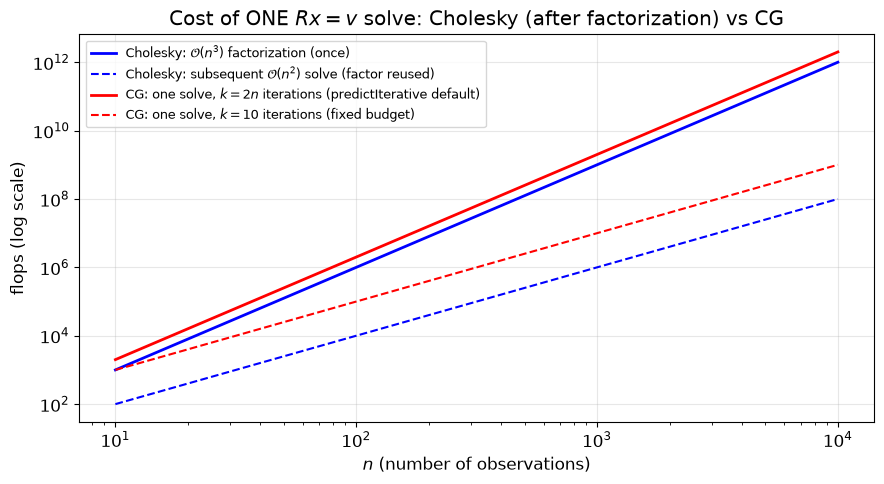

Reading: if the factor L already exists (an ordinarily-fitted model), an O(n^2) Cholesky solve
stays unbeatable. CG becomes worthwhile when L does NOT exist (a light Vecchia/Nystrom/Iterative fit,
or n too large to keep L resident): then the comparison is n^3 (forming L) vs k*n^2 (CG), and CG
wins as soon as k << n -- or simply when you don't want to pay L's O(n^2) memory cost at all.


In [12]:
n_range = np.logspace(1, 4, 60)
cost_chol_factor = n_range**3                  # one factorization
cost_chol_solve  = n_range**2                   # + one solve (reusing L)
cost_cg_default  = 2 * n_range * n_range**2      # k = 2n iterations, one solve
cost_cg_10       = 10 * n_range**2               # fixed budget k=10 iterations

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(n_range, cost_chol_factor, 'b-', lw=2, label=r'Cholesky: $\mathcal{O}(n^3)$ factorization (once)')
ax.loglog(n_range, cost_chol_solve, 'b--', lw=1.5, label=r'Cholesky: subsequent $\mathcal{O}(n^2)$ solve (factor reused)')
ax.loglog(n_range, cost_cg_default, 'r-', lw=2, label=r'CG: one solve, $k=2n$ iterations (predictIterative default)')
ax.loglog(n_range, cost_cg_10, 'r--', lw=1.5, label=r'CG: one solve, $k=10$ iterations (fixed budget)')
ax.set_xlabel('$n$ (number of observations)'); ax.set_ylabel('flops (log scale)')
ax.set_title('Cost of ONE $Rx=v$ solve: Cholesky (after factorization) vs CG')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

print("Reading: if the factor L already exists (an ordinarily-fitted model), an O(n^2) Cholesky solve")
print("stays unbeatable. CG becomes worthwhile when L does NOT exist (a light Vecchia/Nystrom/Iterative fit,")
print("or n too large to keep L resident): then the comparison is n^3 (forming L) vs k*n^2 (CG), and CG")
print("wins as soon as k << n -- or simply when you don't want to pay L's O(n^2) memory cost at all.")

## 6. Going further: ill-conditioned matrices and Nystrom preconditioning

CG converges faster (in practice, well before the theoretical bound $k=n$) the tighter $R$'s spectrum is. Kriging correlation matrices are however often ill-conditioned (smooth kernels, clustered designs): the larger $\theta$ is relative to the spacing between points, the closer $R$ gets to a rank-1 matrix, and the more iterations CG needs to converge.

`predictIterative` offers an optional preconditioner (`use_nystrom_precond=True`): it builds a rank-$k_{\text{precond}}$ Nystrom factorization of $R$ (same landmarks/machinery as `LLNystrom`, see [`Nystrom.md`](Nystrom.md)),

$$R \approx U U^\top, \qquad U = R_{ns}\,L_{ss}^{-\top}\ \ (L_{ss}=\mathrm{chol}(R_{ss}))$$

and uses it as a preconditioner $P^{-1}$ via the Woodbury identity (one-shot cost $\mathcal{O}(n\cdot k_{\text{precond}}^2)$) — the same idea as GPyTorch's pivoted-Cholesky preconditioner. Below we illustrate the effect on a deliberately ill-conditioned case: more points, and an artificially large $\theta$.

In [13]:
# A more ill-conditioned case: more points, a large correlation range (theta imposed)
np.random.seed(1)
n2 = 40
X_o2 = np.sort(np.random.uniform(0, 1, n2)).reshape(-1, 1)
y_o2 = f(X_o2[:, 0])

model_ill = lk.Kriging(y_o2, X_o2, 'gauss', regmodel='constant',
                        parameters={'theta': np.array([[0.8]]), 'estim_theta': False})
R_ill = np.array(model_ill.covMat(X_o2, X_o2)) / model_ill.sigma2()
print(f'condition number of R (theta=0.8, n={n2}):', np.linalg.cond(R_ill))

X_probe = X_grid[::15]   # a handful of prediction points, to keep this fast
mean_ref, _ = model_ill.predict(X_probe, return_stdev=False)[:2]
mean_ref = mean_ref.ravel()

iters_range = np.arange(1, 41, 2)
err_plain, err_precond = [], []
for it in iters_range:
    m_p, _ = model_ill.predictIterative(X_probe, return_stdev=False, max_iter=int(it))
    m_c, _ = model_ill.predictIterative(X_probe, return_stdev=False, max_iter=int(it),
                                  use_nystrom_precond=True, precond_rank=15)
    err_plain.append(np.abs(m_p.ravel() - mean_ref).max())
    err_precond.append(np.abs(m_c.ravel() - mean_ref).max())

condition number of R (theta=0.8, n=40): 5.987672855221417e+17


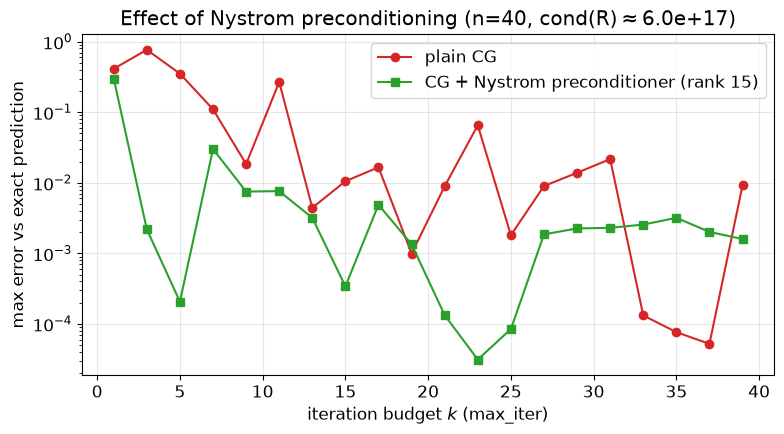

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(iters_range, np.maximum(err_plain, 1e-16), 'o-', color='#d62728', label='plain CG')
ax.semilogy(iters_range, np.maximum(err_precond, 1e-16), 's-', color='#2ca02c', label='CG + Nystrom preconditioner (rank 15)')
ax.set_xlabel("iteration budget $k$ (max_iter)"); ax.set_ylabel('max error vs exact prediction')
ax.set_title(f'Effect of Nystrom preconditioning (n={n2}, cond(R)$\\approx${np.linalg.cond(R_ill):.1e})')
ax.legend(); plt.tight_layout(); plt.show()

On an ill-conditioned matrix, the Nystrom preconditioner reaches a given accuracy with far fewer iterations than plain CG — at the cost of a fixed $\mathcal{O}(n\cdot k_{\text{precond}}^2)$ setup paid once per call. This is opt-in and independent of everything else: neither `predictIterative` nor its preconditioner change the fitted objective, only how the linear systems prediction requires are solved.

## Conclusion

| | Cholesky (`predict`) | Conjugate gradient (`predictIterative`) |
|---|---|---|
| **Idea** | Factorize $R=LL^\top$ once, reuse $L$ | Solve $Rx=v$ iteratively, $R$ never formed |
| **Mean cost** | $\mathcal{O}(n^3)$ once + $\mathcal{O}(n^2)$ per call | $\mathcal{O}(n^2\cdot\text{iters})$, one shared solve |
| **Stdev cost ($q$ points)** | $\mathcal{O}(n^2)$ total (amortized over $L$) | $\mathcal{O}(n^2\cdot\text{iters}\cdot q)$ — one solve per point |
| **Memory** (measured, §5a) | $\mathcal{O}(n^2)$ (resident $L$) | $\mathcal{O}(n)$ ($R$ never materialized) |
| **Exact convergence** | yes, always | yes in exact arithmetic at $k=n$; in practice much sooner if $R$ is well-conditioned |
| **When to use** | Factor already resident, or few predictions needed | Factor never computed (light Vecchia/Nystrom/Iterative fit), or $n$ too large to keep $L$ resident just to predict |

On this 6-point running example, all three computational paths (manual Cholesky, manual CG, `model.predictIterative()`) converge to exactly the same mean **and** the same standard deviation — CG is not a different approximation of the model, it is **another way to compute the same exact result**, with a different cost/memory trade-off, optionally accelerated by Nystrom preconditioning when $R$ is ill-conditioned. The ordinary-kriging correction term from §2 (uncertainty on $\hat m$) is obtained the same way as the mean: one extra shared CG solve instead of a triangular solve.

### References

- Hestenes, M. R., & Stiefel, E. (1952). *Methods of conjugate gradients for solving linear systems*. Journal of Research of the National Bureau of Standards, 49(6), 409-436.
- Williams, C. K. I., & Seeger, M. (2001). *Using the Nystrom method to speed up kernel machines*. NeurIPS 13.
- Gardner, J., Pleiss, G., Weinberger, K. Q., Bindel, D., & Wilson, A. G. (2018). *GPyTorch: Blackbox matrix-matrix Gaussian process inference with GPU acceleration*. NeurIPS 31.
- [`PredictIterative.md`](PredictIterative.md), [`Nystrom.md`](Nystrom.md), [`Scalability.md`](Scalability.md)